# 	Use the Anime Recommendations dataset from below Kaggle link and create an end-to-end project on Jupyter/Colab

## https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database/data

## i.	Download the dataset from above link and load it into your Python environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("anime.csv")

In [3]:
data.shape

(12294, 7)

In [4]:
data.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB


In [6]:
data.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [7]:
data.describe(include='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25616\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,name,genre,type,episodes
count,12294,12232,12269,12294
unique,12292,3264,6,187
top,Saru Kani Gassen,Hentai,TV,1
freq,2,823,3787,5677


In [8]:
data.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

## ii.	Perform the EDA and do the visualizations.

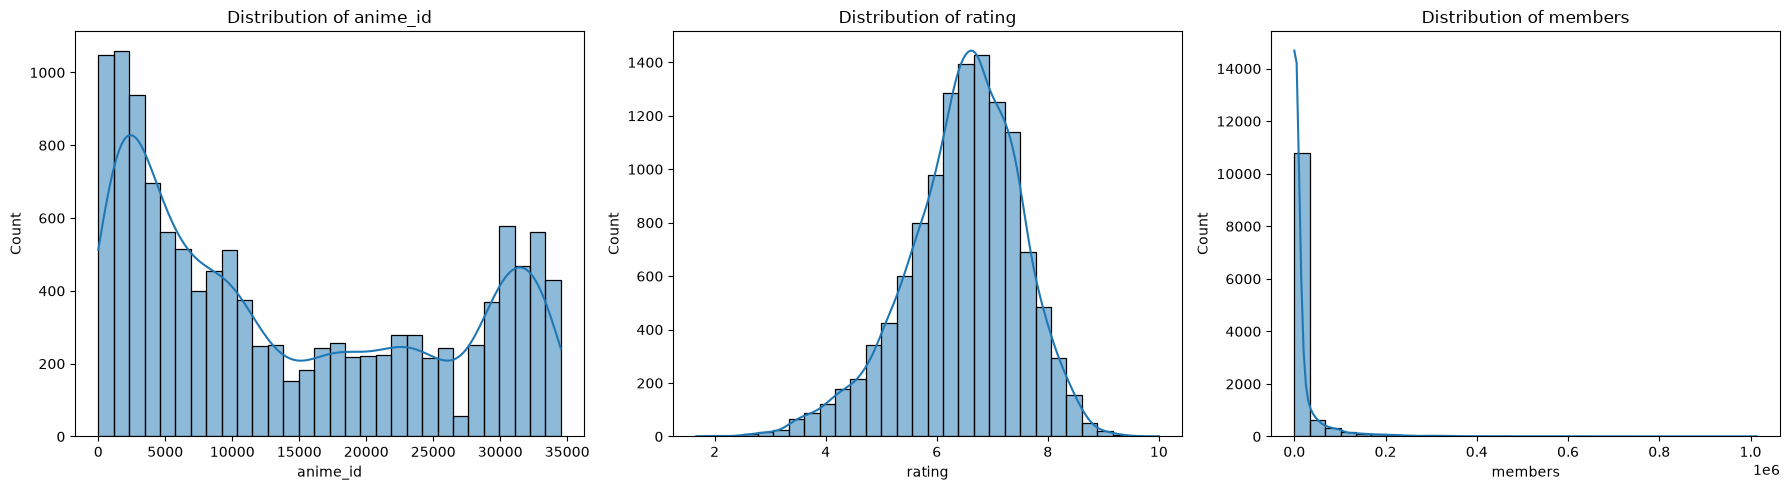

In [10]:
# Distribution Plots
# Numeric columns
num_cols = ['anime_id', 'rating', 'members']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=data,
                 x=col,
                 kde=True,
                 bins=30,
                 ax=axes[i])

    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

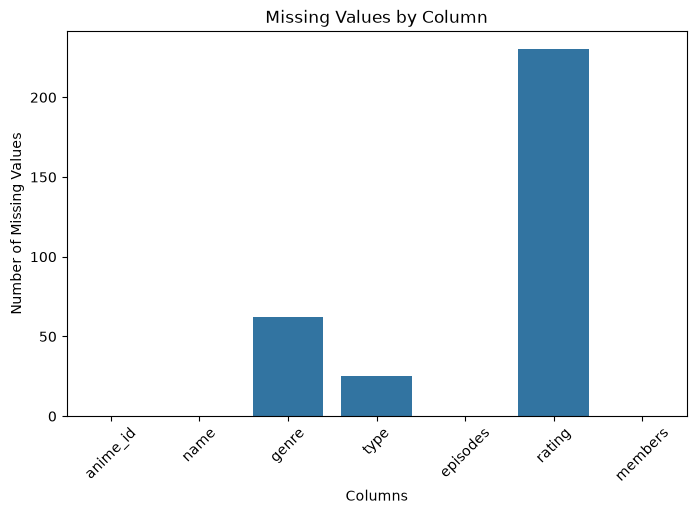

In [11]:
# Missing Values Bar Chart
missing_values = data.isnull().sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)

plt.show()

In [12]:
data['rating'].skew()

np.float64(-0.5435700688578501)

In [13]:
data['genre'].value_counts().shape

(3264,)

In [14]:
data['type'].value_counts()

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

In [15]:
# Fill missing ratings with median
data['rating'] = data['rating'].fillna(data['rating'].median())

# Fill missing type with mode (most frequent value)
data['type'] = data['type'].fillna(data['type'].mode()[0])

# Drop rows where genre is missing
data = data.dropna(subset=['genre'])

# Verify missing values
data.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [16]:
data.shape

(12232, 7)

In [17]:
print("Rows after cleaning:", data.shape[0])
print("Columns after cleaning:", data.shape[1])

Rows after cleaning: 12232
Columns after cleaning: 7


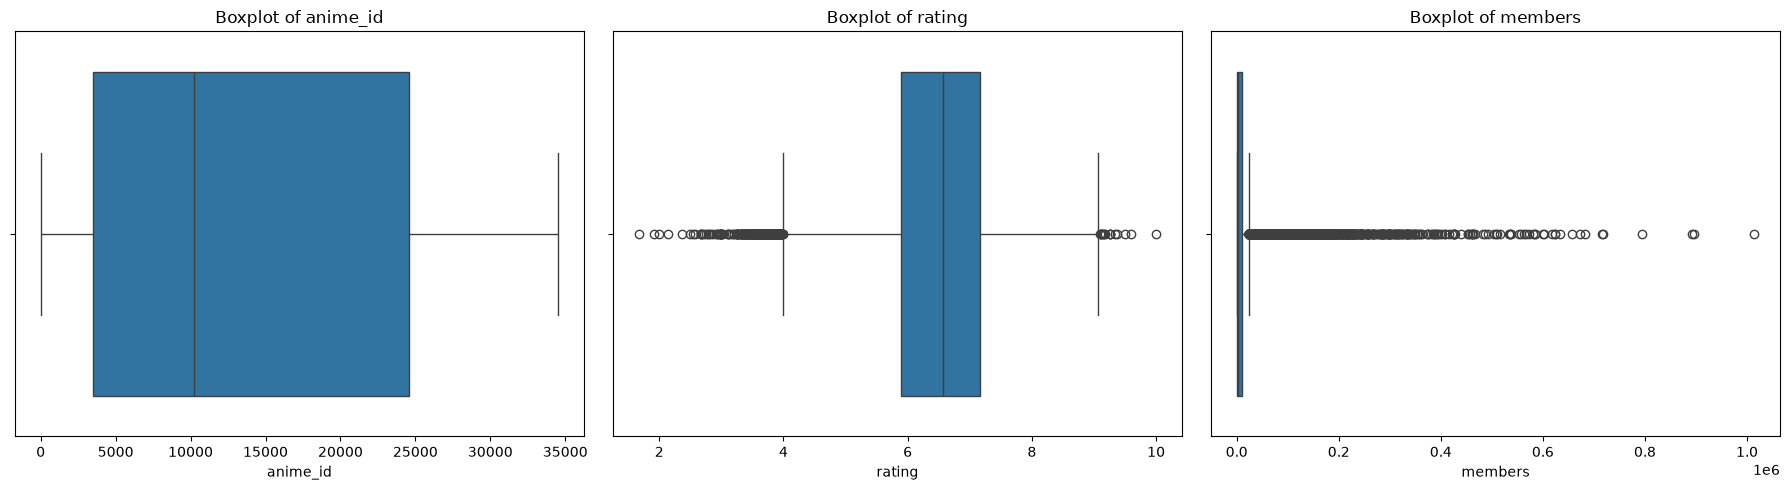

In [18]:
# Boxplots (Good for Skewness & Outliers)
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['anime_id', 'rating', 'members']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x=data[col], ax=axes[i])

    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#### The rating feature exhibited a small number of outliers according to the IQR method. However, these observations represent valid anime ratings within the expected rating scale and are therefore retained. No outlier treatment was applied to the rating feature.

In [19]:
# Check skewness
data[['rating', 'members']].skew()

rating    -0.553798
members    6.666591
dtype: float64

In [20]:
#Detect Outliers in rating
Q1 = data['rating'].quantile(0.25)
Q3 = data['rating'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rating_outliers = data[
    (data['rating'] < lower_bound) |
    (data['rating'] > upper_bound)
]

print("Number of rating outliers:", rating_outliers.shape[0])

Number of rating outliers: 247


In [21]:
#Detect Outliers in members
Q1 = data['members'].quantile(0.25)
Q3 = data['members'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

members_outliers = data[
    (data['members'] < lower_bound) |
    (data['members'] > upper_bound)
]

print("Number of members outliers:", members_outliers.shape[0])

Number of members outliers: 1895


In [22]:
# Treatment: Log Transformation

data['members_log'] = np.log1p(data['members'])

In [23]:
data['members_log'].skew()

np.float64(0.26303223595978464)

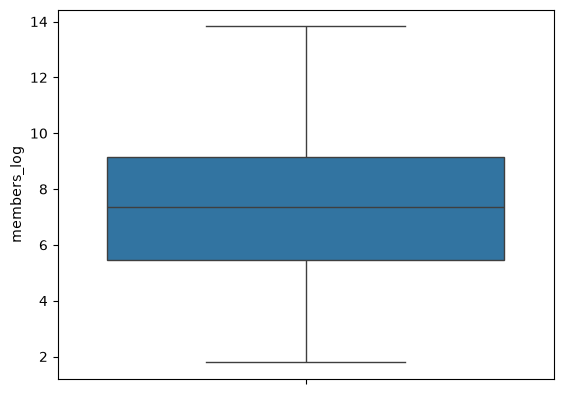

In [24]:
sns.boxplot(data=data.members_log)
plt.show()

In [25]:
data.head()

,anime_id,name,genre,type,episodes,rating,members,members_log
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,12.209223
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665,13.584418
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262,11.646258
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,13.420352
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266,11.926802


In [26]:
# Drop original members column
data.drop(columns=['members'], inplace=True)

# Rename members_log to members
data.rename(columns={'members_log': 'members'}, inplace=True)

# Verify
data.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,12.209223
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,13.584418
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,11.646258
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,13.420352
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,11.926802


In [27]:
# Create a Feature Column
# Combine useful content features:

data['features'] = (
    data['genre'].astype(str) + ' ' +
    data['type'].astype(str)
)

In [28]:
# Convert Text into Numerical Vectors
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(data['features'])

In [29]:
# Calculate Similarity
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [30]:
# Create Index Mapping
indices = pd.Series(
    data.index,
    index=data['name']
).drop_duplicates()

In [31]:
# Recommendation Function
def recommend_anime(anime_name, n=10):

    idx = indices[anime_name]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:n+1]

    anime_indices = [i[0] for i in sim_scores]

    return data[['name', 'genre', 'rating']].iloc[anime_indices]

In [32]:
# Test the System

print(recommend_anime('Naruto'))
print(recommend_anime('Death Note'))

                                                   name  \
841                                              Naruto   
1343                                        Naruto x UT   
1796                                     Rekka no Honoo   
486                            Boruto: Naruto the Movie   
1472        Naruto: Shippuuden Movie 4 - The Lost Tower   
1573  Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...   
2997  Naruto Soyokazeden Movie: Naruto to Mashin to ...   
2342                             Kurokami The Animation   
2852                                       Project ARMS   
6163                                          Wolverine   

                                                  genre  rating  
841   Action, Comedy, Martial Arts, Shounen, Super P...    7.81  
1343  Action, Comedy, Martial Arts, Shounen, Super P...    7.58  
1796  Action, Adventure, Martial Arts, Shounen, Supe...    7.44  
486   Action, Comedy, Martial Arts, Shounen, Super P...    8.03  
1472  Action, Comedy

In [33]:
print(recommend_anime('Dragon Ball Z'))

                                                   name  \
515                              Dragon Ball Kai (2014)   
588                                     Dragon Ball Kai   
1930                                  Dragon Ball Super   
346                                         Dragon Ball   
4275               Dragon Ball Z: Atsumare! Gokuu World   
1796                                     Rekka no Honoo   
1409              Dragon Ball Z Movie 15: Fukkatsu no F   
5999  Dragon Ball Z Movie 11: Super Senshi Gekiha!! ...   
3203             Dragon Ball Z: Summer Vacation Special   
4314  Dragon Ball GT: Goku Gaiden! Yuuki no Akashi w...   

                                                  genre  rating  
515   Action, Adventure, Comedy, Fantasy, Martial Ar...    8.01  
588   Action, Adventure, Comedy, Fantasy, Martial Ar...    7.95  
1930  Action, Adventure, Comedy, Fantasy, Martial Ar...    7.40  
346   Adventure, Comedy, Fantasy, Martial Arts, Shou...    8.16  
4275  Action, Advent

In [34]:
print(recommend_anime("Akira"))

                                       name  \
3259        Manie-Manie: Meikyuu Monogatari   
11950                         Megami Kyouju   
1849                   Biohazard: Damnation   
2668                Biohazard: Degeneration   
3732   Highlander: The Search for Vengeance   
8715                              Guilstein   
10946                   Biohazard: Vendetta   
3280             Vexille: 2077 Nihon Sakoku   
3779            Starship Troopers: Invasion   
6963                              Ice Movie   

                                                  genre  rating  
3259   Adventure, Fantasy, Horror, Sci-Fi, Supernatural    7.04  
11950    Hentai, Horror, Military, Sci-Fi, Supernatural    5.85  
1849                             Action, Horror, Sci-Fi    7.42  
2668                             Action, Horror, Sci-Fi    7.19  
3732                             Action, Horror, Sci-Fi    6.90  
8715                             Action, Horror, Sci-Fi    5.33  
10946               

In [35]:
recommend_anime("Berserk")

,name,genre,rating
4052,Berserk (2016),"Action, Adventure, Demons, Drama, Fantasy, Hor...",6.81
198,Berserk: Ougon Jidai-hen III - Kourin,"Action, Adventure, Demons, Drama, Fantasy, Hor...",8.33
419,Berserk: Ougon Jidai-hen II - Doldrey Kouryaku,"Action, Adventure, Demons, Drama, Fantasy, Hor...",8.09
10924,Berserk (2017),"Action, Adventure, Demons, Drama, Fantasy, Hor...",6.57
657,Berserk: Ougon Jidai-hen I - Haou no Tamago,"Action, Adventure, Demons, Fantasy, Military, ...",7.91
1312,Kemonozume,"Action, Demons, Horror, Romance, Supernatural",7.59
1290,Otome Youkai Zakuro,"Demons, Historical, Military, Romance, Seinen,...",7.60
2901,3x3 Eyes Seima Densetsu,"Action, Adventure, Demons, Fantasy, Horror, Ro...",7.13
5095,Devilman,"Action, Demons, Horror, Supernatural",6.55
3398,Zetman,"Action, Drama, Horror, Romance, Sci-Fi, Seinen...",7.01


# Conclusion

In this project, the Anime Recommendation dataset was analyzed and processed to build a Content-Based Recommendation System. The dataset was first explored using Exploratory Data Analysis (EDA) to understand its structure, missing values, distributions, and key characteristics.

Missing values were identified and handled appropriately. The numerical features were analyzed for skewness and outliers. The `members` feature exhibited high positive skewness and was transformed using a logarithmic transformation, which reduced skewness significantly and improved the distribution of the data. The outliers in the rating feature were found to be genuine observations and were therefore retained.

For the recommendation engine, relevant content features such as genre and type were combined and transformed into numerical vectors using TF-IDF Vectorization. Cosine Similarity was then used to measure the similarity between anime titles. Based on these similarity scores, a Content-Based Recommendation System was developed that recommends anime with similar characteristics to a selected anime.

The final model successfully generates relevant anime recommendations based on content features and demonstrates the practical application of machine learning techniques in recommendation systems. This project highlights the importance of data preprocessing, feature engineering, and similarity-based modeling in building effective recommendation systems.


In [36]:
# Normalize Rating and Members
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data['rating_score'] = scaler.fit_transform(
    data[['rating']]
)

data['popularity_score'] = scaler.fit_transform(
    data[['members']]
)

# Hybrid Recommendation Function

In [37]:
# Hybrid Recommendation Function
def hybrid_recommendation(
    anime_name,
    n=10,
    content_weight=0.6,
    rating_weight=0.2,
    popularity_weight=0.2
):

    idx = indices[anime_name]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    recommendations = []

    for anime_idx, similarity in sim_scores:

        final_score = (
            content_weight * similarity
            + rating_weight * data.iloc[anime_idx]['rating_score']
            + popularity_weight * data.iloc[anime_idx]['popularity_score']
        )

        recommendations.append(
            (anime_idx, final_score)
        )

    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = recommendations[1:n+1]

    anime_indices = [
        i[0] for i in recommendations
    ]

    return data[
        ['name', 'genre', 'rating', 'members']
    ].iloc[anime_indices]

In [38]:
#Test
hybrid_recommendation(
    'Naruto',
    n=10
) 

,name,genre,rating,members
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",7.94,13.187362
206,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",8.32,12.836448
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",8.16,12.663823
588,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",7.95,11.668501
486,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",8.03,11.221115
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",7.53,11.344838
1573,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.50,11.332794
1930,Dragon Ball Super,"Action, Adventure, Comedy, Fantasy, Martial Ar...",7.40,11.621278
515,Dragon Ball Kai (2014),"Action, Adventure, Comedy, Fantasy, Martial Ar...",8.01,10.661181
2342,Kurokami The Animation,"Action, Martial Arts, Super Power",7.29,11.194798


In [39]:
hybrid_recommendation('Death Note',n=5)

,name,genre,rating,members
981,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",7.74,11.832746
778,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",7.84,11.393015
144,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",8.41,12.292718
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",8.07,13.395730
38,Monster,"Drama, Horror, Mystery, Police, Psychological,...",8.72,12.419420


In [40]:
hybrid_recommendation(
    'Hunter x Hunter',
    n=5
)

,name,genre,rating,members
112,Hunter x Hunter,"Action, Adventure, Shounen, Super Power",8.48,12.021284
175,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",8.37,12.461118
74,One Piece,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",8.58,13.132042
146,Hunter x Hunter: Greed Island Final,"Action, Adventure, Shounen, Super Power",8.41,10.929314
145,Hunter x Hunter OVA,"Action, Adventure, Shounen, Super Power",8.41,10.881231


In [41]:
#Semi-Automatic Evaluation (Portfolio Level)

def genre_overlap_score(input_anime, recommended_anime):

    input_genres = set(
        data[data['name']==input_anime]
        ['genre']
        .iloc[0]
        .split(', ')
    )

    rec_genres = set(
        data[data['name']==recommended_anime]
        ['genre']
        .iloc[0]
        .split(', ')
    )

    overlap = len(
        input_genres.intersection(rec_genres)
    )

    score = overlap / len(input_genres)

    return round(score,2)

In [42]:
genre_overlap_score(
    'Naruto',
    'Naruto: Shippuuden'
)

1.0

### Genre Overlap Score was used as a semi-automatic evaluation metric. A score of 1.0 indicates complete genre similarity between the input anime and the recommended anime, while lower scores indicate partial genre overlap. This metric helps validate that the recommendation engine is suggesting content-relevant anime.

In [43]:
import pickle

# Save dataframe
pickle.dump(data, open('anime_data.pkl', 'wb'))

# Save cosine similarity matrix
pickle.dump(cosine_sim, open('cosine_sim.pkl', 'wb'))

# Save indices mapping
pickle.dump(indices, open('indices.pkl', 'wb'))

In [45]:
import pickle

anime_df = pickle.load(open("anime_data.pkl", "rb"))

print("Columns:")
print(anime_df.columns.tolist())

print("\nFirst 5 rows:")
print(anime_df.head())



Columns:
['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members', 'features', 'rating_score', 'popularity_score']

First 5 rows:
   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

     members                                           features  rating_score  \


In [46]:
import pickle

indices = pickle.load(open("indices.pkl","rb"))
print(type(indices))
print(indices.head() if hasattr(indices, "head") else indices)

<class 'pandas.Series'>
name
Kimi no Na wa.                      0
Fullmetal Alchemist: Brotherhood    1
Gintama°                            2
Steins;Gate                         3
Gintama&#039;                       4
dtype: int64


In [47]:
import pickle

cosine_sim = pickle.load(open("cosine_sim.pkl","rb"))
print(type(cosine_sim))
print(cosine_sim.shape)

<class 'numpy.ndarray'>
(12232, 12232)


In [48]:
print(anime_df.head(10))

   anime_id                                               name  \
0     32281                                     Kimi no Na wa.   
1      5114                   Fullmetal Alchemist: Brotherhood   
2     28977                                           Gintama°   
3      9253                                        Steins;Gate   
4      9969                                      Gintama&#039;   
5     32935  Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...   
6     11061                             Hunter x Hunter (2011)   
7       820                               Ginga Eiyuu Densetsu   
8     15335  Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...   
9     15417                           Gintama&#039;: Enchousen   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Pa